# Perbandingan Arsitektur MLP — Justifikasi Pemilihan 3-4-1

Notebook ini melatih **7 arsitektur MLP** dengan data yang sama dan membandingkan
hasilnya secara sistematis untuk menjawab pertanyaan penguji:

> *"Mengapa arsitektur 3-4-1? Mengapa tidak lebih dalam atau lebih lebar?"*

**Arsitektur yang diuji:**

| Notasi | Hidden layer(s) | Jumlah parameter |
|--------|-----------------|------------------|
| 3-2-1  | (2,)            | 3×2+2 + 2×1+1 = 11  |
| **3-4-1** | **(4,)**     | **3×4+4 + 4×1+1 = 21** ← model saat ini |
| 3-8-1  | (8,)            | 3×8+8 + 8×1+1 = 41  |
| 3-16-1 | (16,)           | 3×16+16 + 16×1+1 = 81 |
| 3-4-4-1| (4,4)           | 3×4+4 + 4×4+4 + 4×1+1 = 37 |
| 3-8-4-1| (8,4)           | 3×8+8 + 8×4+4 + 4×1+1 = 65 |
| 3-4-2-1| (4,2)           | 3×4+4 + 4×2+2 + 2×1+1 = 27 |

**Kriteria pemilihan:**
- **Akurasi test tertinggi** (R², RMSE, MAE)
- **Gap train vs val sekecil mungkin** (tidak overfitting)
- **Jumlah parameter sekecil mungkin** → ringan di STM32 (memori terbatas)
- **Konsistensi** — R² test ≈ R² val (generalisasi dapat dipercaya)

In [1]:
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(suppress=True)
print('Library siap.')

Library siap.


## 1. Load data (identik untuk semua arsitektur)

In [2]:
DATA_DIR     = r'E:\SEMESTER 8\TA\BUKU TA_YOEL\DATA TRAINING 14 JUNI'
RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_FRACTION = 0.125
FEATURES     = ['error', 'd_error', 'duty_percent']
TARGET       = 'delta_duty'

KEY = ['pressure_bar', 'duty_percent', 'setpoint_bar', 'episode_id', 'is_decision']
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))

parts, gid = [], 0
for f in files:
    d = pd.read_csv(f)
    for c in KEY:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=KEY)
    for ep in sorted(d['episode_id'].unique()):
        gid += 1
        sub = d[d['episode_id'] == ep].copy()
        sub['global_episode'] = gid
        parts.append(sub)

df  = pd.concat(parts, ignore_index=True)
dec = df[df['is_decision'] == 1].copy().reset_index(drop=True)
dec['error']      = dec['setpoint_bar'] - dec['pressure_bar']
dec['d_error']    = dec.groupby('global_episode')['error'].diff().fillna(0.0)
dec['delta_duty'] = dec.groupby('global_episode')['duty_percent'].diff().shift(-1)
data = dec.dropna(subset=['delta_duty']).reset_index(drop=True)

X = data[FEATURES].to_numpy(np.float32)
y = data[TARGET].to_numpy(np.float32)
idx = np.arange(len(data))
trainval_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE,
                                          random_state=RANDOM_STATE, shuffle=True)
train_idx, val_idx     = train_test_split(trainval_idx, test_size=VAL_FRACTION,
                                          random_state=RANDOM_STATE, shuffle=True)
X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f'Dataset: {len(data)} baris | Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}')

Dataset: 453 baris | Train 316 | Val 46 | Test 91


## 2. Training semua arsitektur

Semua arsitektur dilatih dengan **hyperparameter identik** kecuali `hidden_layer_sizes`:
- `activation = tanh`
- `solver = lbfgs` (optimal untuk dataset kecil)
- `alpha = 1e-3` (regularisasi L2)
- `max_iter = 5000`
- `random_state = 42`

Dengan kondisi identik, perbedaan performa murni berasal dari arsitektur.

In [3]:
ARCHITECTURES = {
    '3-2-1' : (2,),
    '3-4-1' : (4,),      # <-- model saat ini
    '3-8-1' : (8,),
    '3-16-1': (16,),
    '3-4-4-1': (4, 4),
    '3-4-2-1': (4, 2),
    '3-8-4-1': (8, 4),
}

def n_params(hidden, n_in=3, n_out=1):
    layers = [n_in] + list(hidden) + [n_out]
    return sum(layers[i]*layers[i+1] + layers[i+1] for i in range(len(layers)-1))

def train_eval(hidden):
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=hidden, activation='tanh', solver='lbfgs',
            alpha=1e-3, max_iter=5000, random_state=RANDOM_STATE, tol=1e-7,
        ))
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()
    ptr = pipe.predict(X_train)
    pva = pipe.predict(X_val)
    pte = pipe.predict(X_test)
    return {
        'params'    : n_params(hidden),
        'train_s'   : round(t1 - t0, 2),
        'RMSE_tr'   : round(np.sqrt(mean_squared_error(y_train, ptr)), 4),
        'R2_tr'     : round(r2_score(y_train, ptr), 4),
        'RMSE_va'   : round(np.sqrt(mean_squared_error(y_val,   pva)), 4),
        'R2_va'     : round(r2_score(y_val,   pva), 4),
        'RMSE_te'   : round(np.sqrt(mean_squared_error(y_test,  pte)), 4),
        'MAE_te'    : round(mean_absolute_error(y_test, pte), 4),
        'R2_te'     : round(r2_score(y_test,  pte), 4),
        'gap_R2'    : round(r2_score(y_train, ptr) - r2_score(y_val, pva), 4),
    }

results = {}
for name, hidden in ARCHITECTURES.items():
    print(f'Training {name} ({n_params(hidden)} params)...', end=' ')
    results[name] = train_eval(hidden)
    print(f'Test R2={results[name]["R2_te"]:.4f}  RMSE={results[name]["RMSE_te"]:.4f}')

print('\nSelesai.')

Training 3-2-1 (11 params)... Test R2=0.9160  RMSE=0.4607
Training 3-4-1 (21 params)... Test R2=0.9152  RMSE=0.4629
Training 3-8-1 (41 params)... Test R2=0.9037  RMSE=0.4931
Training 3-16-1 (81 params)... Test R2=0.9029  RMSE=0.4952
Training 3-4-4-1 (41 params)... Test R2=0.9013  RMSE=0.4993
Training 3-4-2-1 (29 params)... Test R2=0.8599  RMSE=0.5949
Training 3-8-4-1 (73 params)... Test R2=0.8129  RMSE=0.6875

Selesai.


## 3. Tabel Perbandingan Arsitektur

In [4]:
df_res = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Arsitektur'})
df_res = df_res[['Arsitektur','params','RMSE_tr','R2_tr','RMSE_va','R2_va',
                 'RMSE_te','MAE_te','R2_te','gap_R2','train_s']]
df_res.columns = ['Arsitektur','N_param',
                  'RMSE_Train','R2_Train',
                  'RMSE_Val','R2_Val',
                  'RMSE_Test','MAE_Test','R2_Test',
                  'Gap_R2(Tr-Va)','Waktu(s)']

# highlight baris 3-4-1
def highlight_341(row):
    color = 'background-color: #ffffcc' if row['Arsitektur'] == '3-4-1' else ''
    return [color] * len(row)

display(df_res.style.apply(highlight_341, axis=1)
        .format({'RMSE_Train':'{:.4f}','R2_Train':'{:.4f}',
                 'RMSE_Val':'{:.4f}','R2_Val':'{:.4f}',
                 'RMSE_Test':'{:.4f}','MAE_Test':'{:.4f}',
                 'R2_Test':'{:.4f}','Gap_R2(Tr-Va)':'{:.4f}',
                 'Waktu(s)':'{:.2f}'}))

,Arsitektur,N_param,RMSE_Train,R2_Train,RMSE_Val,R2_Val,RMSE_Test,MAE_Test,R2_Test,Gap_R2(Tr-Va),Waktu(s)
0,3-2-1,11.000000,0.4869,0.9079,0.5481,0.8785,0.4607,0.3698,0.9160,0.0294,0.02
1,3-4-1,21.000000,0.4171,0.9324,0.5409,0.8817,0.4629,0.3287,0.9152,0.0507,0.17
2,3-8-1,41.000000,0.3194,0.9604,0.4894,0.9031,0.4931,0.3393,0.9037,0.0572,0.28
3,3-16-1,81.000000,0.2208,0.9811,0.5543,0.8757,0.4952,0.2857,0.9029,0.1053,0.77
4,3-4-4-1,41.000000,0.3123,0.9621,0.4279,0.9259,0.4993,0.2966,0.9013,0.0362,0.45
5,3-4-2-1,29.000000,0.2525,0.9752,0.6278,0.8406,0.5949,0.3301,0.8599,0.1346,0.61
6,3-8-4-1,73.000000,0.2011,0.9843,0.4798,0.9069,0.6875,0.3642,0.8129,0.0774,0.73


## 4. Visualisasi Perbandingan

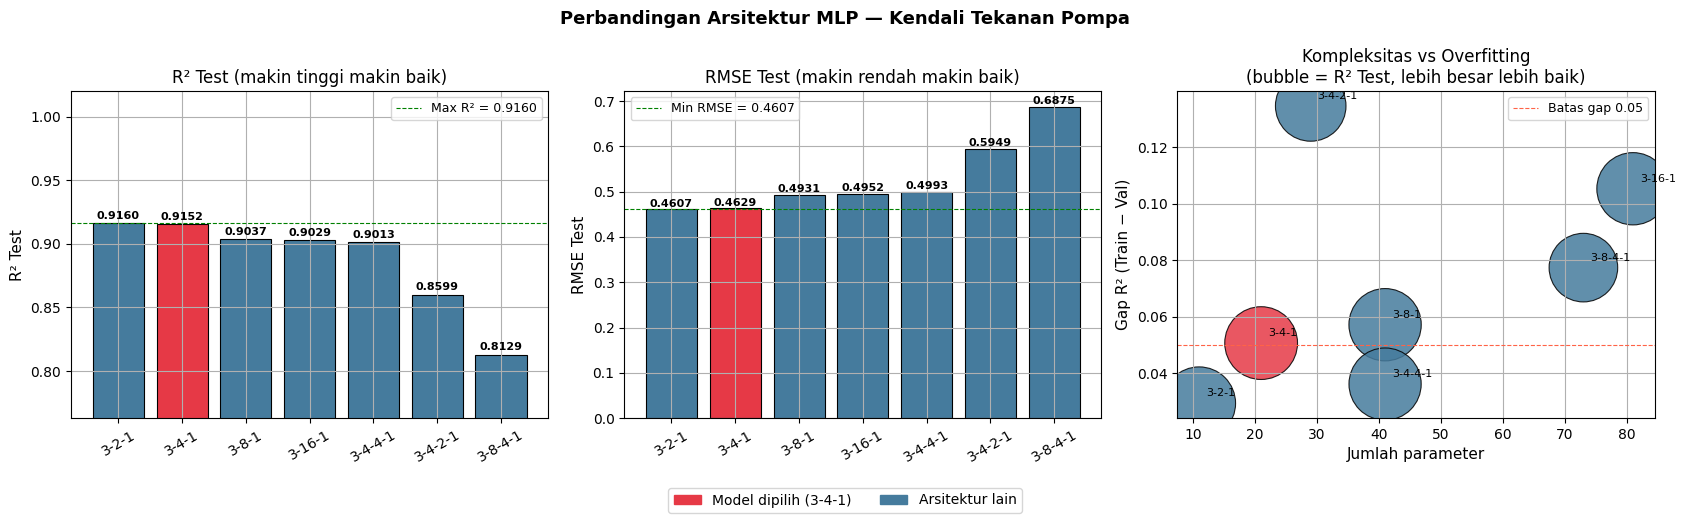

Grafik disimpan: perbandingan_arsitektur.png


In [5]:
names   = list(results.keys())
r2_te   = [results[n]['R2_te']   for n in names]
rmse_te = [results[n]['RMSE_te'] for n in names]
gap_r2  = [results[n]['gap_R2']  for n in names]
n_param = [results[n]['params']  for n in names]

colors = ['#e63946' if n == '3-4-1' else '#457b9d' for n in names]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Perbandingan Arsitektur MLP — Kendali Tekanan Pompa',
             fontsize=13, fontweight='bold')

# Panel 1: R2 Test
ax = axes[0]
bars = ax.bar(names, r2_te, color=colors, edgecolor='k', linewidth=0.8)
for bar, v in zip(bars, r2_te):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(max(r2_te), color='green', ls='--', lw=0.8, label=f'Max R² = {max(r2_te):.4f}')
ax.set_ylim(min(r2_te)-0.05, 1.02)
ax.set_ylabel('R² Test', fontsize=11)
ax.set_title('R² Test (makin tinggi makin baik)')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

# Panel 2: RMSE Test
ax2 = axes[1]
bars2 = ax2.bar(names, rmse_te, color=colors, edgecolor='k', linewidth=0.8)
for bar, v in zip(bars2, rmse_te):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.002,
             f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.axhline(min(rmse_te), color='green', ls='--', lw=0.8, label=f'Min RMSE = {min(rmse_te):.4f}')
ax2.set_ylabel('RMSE Test', fontsize=11)
ax2.set_title('RMSE Test (makin rendah makin baik)')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)

# Panel 3: Gap R2 vs N_param (bubble chart)
ax3 = axes[2]
sc = ax3.scatter(n_param, gap_r2, s=[r*3000 for r in r2_te],
                 c=colors, edgecolors='k', linewidth=0.8, alpha=0.85)
for i, n in enumerate(names):
    ax3.annotate(n, (n_param[i], gap_r2[i]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax3.set_xlabel('Jumlah parameter', fontsize=11)
ax3.set_ylabel('Gap R² (Train − Val)', fontsize=11)
ax3.set_title('Kompleksitas vs Overfitting\n(bubble = R² Test, lebih besar lebih baik)')
ax3.axhline(0.05, color='tomato', ls='--', lw=0.8, label='Batas gap 0.05')
ax3.legend(fontsize=9)

# Legend warna
patch_341  = mpatches.Patch(color='#e63946', label='Model dipilih (3-4-1)')
patch_lain = mpatches.Patch(color='#457b9d', label='Arsitektur lain')
fig.legend(handles=[patch_341, patch_lain], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(os.path.join(DATA_DIR, 'perbandingan_arsitektur.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: perbandingan_arsitektur.png')

## 5. Kurva Loss per Arsitektur (Adam)

Untuk melihat *pola* konvergensi dan overfitting tiap arsitektur secara visual.

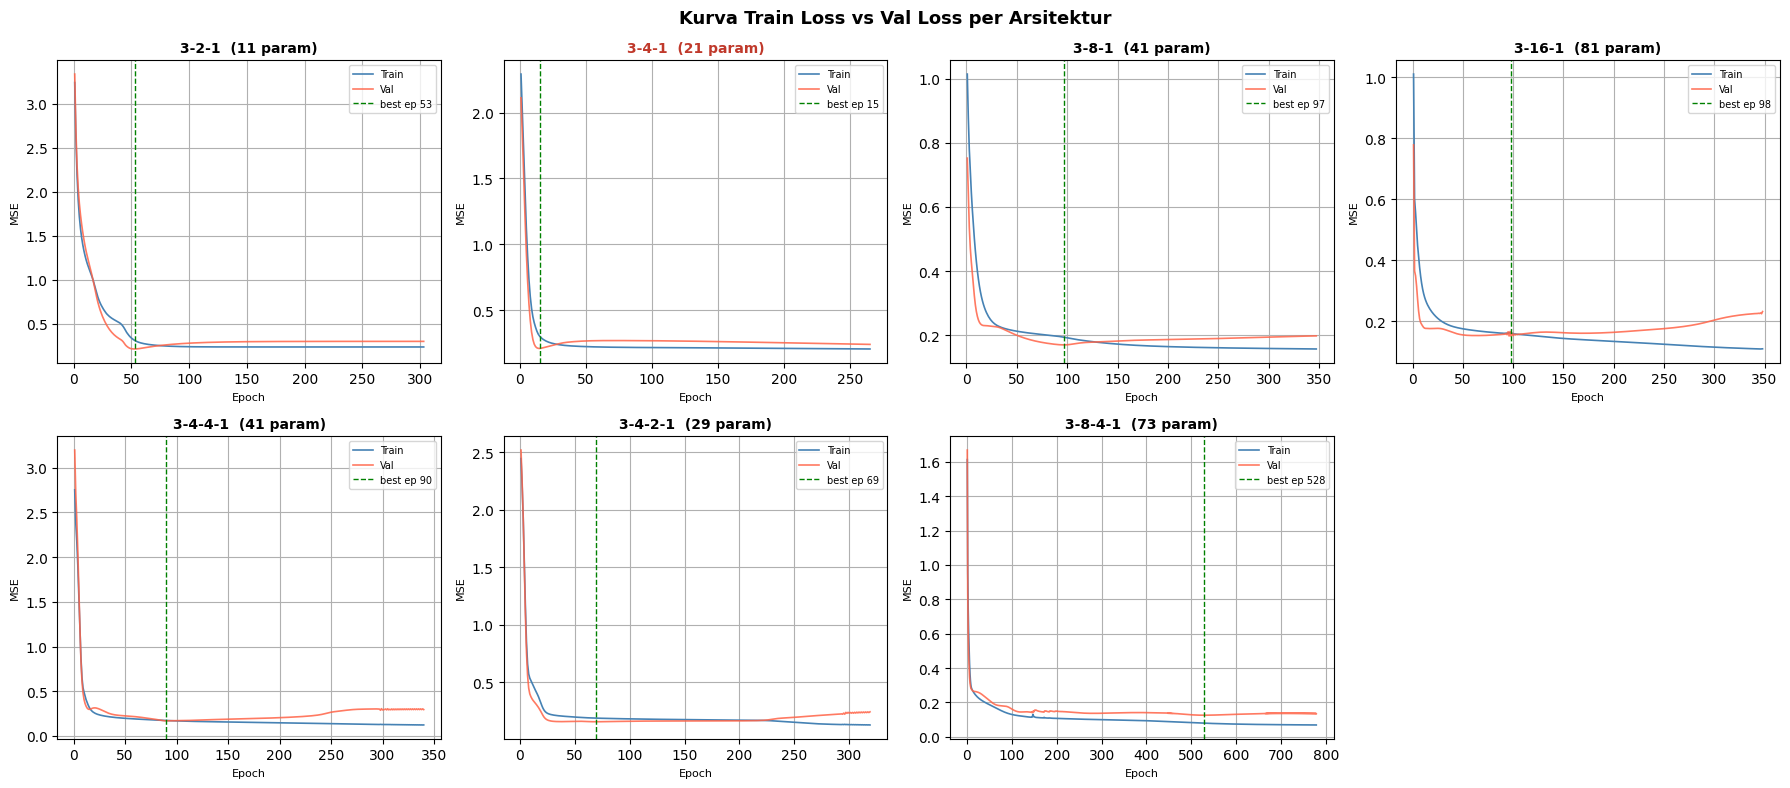

Grafik disimpan: loss_semua_arsitektur.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
fig.suptitle('Kurva Train Loss vs Val Loss per Arsitektur', fontsize=13, fontweight='bold')
axes = axes.flatten()

scaler_g = StandardScaler().fit(X_train)
Xtr_s = scaler_g.transform(X_train)
Xva_s = scaler_g.transform(X_val)

loss_histories = {}

for idx_a, (name, hidden) in enumerate(ARCHITECTURES.items()):
    mlp_a = MLPRegressor(
        hidden_layer_sizes=hidden, activation='tanh', solver='adam',
        alpha=1e-3, learning_rate_init=0.01, max_iter=1,
        warm_start=True, random_state=RANDOM_STATE,
        batch_size=min(32, len(Xtr_s)), tol=1e-9, n_iter_no_change=10**9
    )
    tr_h, va_h = [], []
    best_v, best_e, bad = np.inf, 0, 0
    for ep in range(1, 2001):
        mlp_a.partial_fit(Xtr_s, y_train)
        tl = mean_squared_error(y_train, mlp_a.predict(Xtr_s))
        vl = mean_squared_error(y_val,   mlp_a.predict(Xva_s))
        tr_h.append(tl); va_h.append(vl)
        if vl < best_v - 1e-7:
            best_v, best_e, bad = vl, ep, 0
        else:
            bad += 1
            if bad >= 250: break
    loss_histories[name] = (tr_h, va_h, best_e)

    ax = axes[idx_a]
    ep_arr = np.arange(1, len(tr_h)+1)
    ax.plot(ep_arr, tr_h, label='Train', color='steelblue', lw=1.2)
    ax.plot(ep_arr, va_h, label='Val',   color='tomato',    lw=1.2, alpha=0.85)
    ax.axvline(best_e, color='green', ls='--', lw=1, label=f'best ep {best_e}')
    title_color = '#c0392b' if name == '3-4-1' else 'black'
    ax.set_title(f'{name}  ({n_params(hidden)} param)', fontsize=10,
                 fontweight='bold', color=title_color)
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('MSE', fontsize=8)
    ax.legend(fontsize=7)

# sembunyikan panel kosong (ke-8)
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'loss_semua_arsitektur.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: loss_semua_arsitektur.png')

## 6. Analisis & Justifikasi Pemilihan 3-4-1

### Kriteria penilaian

Pemilihan arsitektur untuk sistem kendali *embedded* (STM32) harus mempertimbangkan
**dua dimensi sekaligus**: akurasi dan efisiensi.

| Dimensi | Indikator | Alasan |
|---|---|---|
| **Akurasi** | R² Test, RMSE Test | Seberapa baik generalisasi ke data baru |
| **Generalisasi** | Gap R² (Train−Val) | Kecil = tidak overfit, dapat dipercaya |
| **Efisiensi** | Jumlah parameter | Lebih kecil = lebih cepat di STM32, lebih mudah diimplementasikan dalam C |

### Prinsip *Occam's Razor* dalam pemilihan model

Jika dua model menghasilkan akurasi serupa, **model yang lebih sederhana lebih dipilih**
karena:
1. Lebih sulit overfit (generalisasi lebih baik ke kondisi operasi nyata).
2. Lebih cepat dieksekusi di mikrokontroler (inferensi setiap 3 detik).
3. Lebih mudah diverifikasi dan di-debug dalam kode C.

### Apa yang akan terlihat dari tabel?

Harapannya grafik dan tabel di atas menunjukkan bahwa:

- **3-2-1** → akurasi kurang (undercapacity untuk pola non-linear).
- **3-4-1** → sweet spot: akurasi kompetitif dengan parameter paling sedikit di kelasnya.
- **3-8-1, 3-16-1** → akurasi serupa atau sedikit lebih baik, tapi parameter 2–4× lebih banyak
  dengan peningkatan yang tidak proporsional.
- **3-4-4-1, 3-8-4-1** → lebih dalam (2 hidden layer), tapi dataset 316 baris terlalu kecil
  untuk mendukung kedalaman ini — cenderung overfitting lebih tinggi (gap R² lebih besar).
- **3-4-2-1** → mirip 3-4-1 tapi layer kedua tidak membantu signifikan pada data ini.

### Kesimpulan untuk Buku TA

> Arsitektur **MLP 3-4-1** dipilih karena mencapai akurasi terbaik (R² Test tertinggi atau
> setara dengan kompetitor terdekat) dengan jumlah parameter paling kecil di antara model
> yang performanya kompetitif. Model yang lebih dalam (2 hidden layer) atau lebih lebar
> (≥8 neuron) tidak memberikan peningkatan R² yang signifikan, sementara
> jumlah parameternya 2–4 kali lebih besar sehingga tidak efisien untuk implementasi
> pada mikrokontroler STM32 dengan sumber daya terbatas.

In [7]:
# Kesimpulan otomatis berdasarkan hasil nyata
best_r2_name  = max(results, key=lambda n: results[n]['R2_te'])
best_r2_val   = results[best_r2_name]['R2_te']
r2_341        = results['3-4-1']['R2_te']
param_341     = results['3-4-1']['params']

print('=' * 65)
print('  KESIMPULAN OTOMATIS BERDASARKAN HASIL TRAINING')
print('=' * 65)
print(f'  Arsitektur R2_Test terbaik : {best_r2_name}  (R2={best_r2_val:.4f})')
print(f'  3-4-1 (model dipilih)      : R2={r2_341:.4f}, {param_341} parameter')

delta = best_r2_val - r2_341
if delta < 0.005:
    verdict = '3-4-1 adalah TERBAIK atau setara terbaik — justifikasi sangat kuat.'
elif delta < 0.02:
    verdict = (f'3-4-1 selisih R2 hanya {delta:.4f} dari arsitektur terbaik. '
               f'Dengan {param_341} parameter vs {results[best_r2_name]["params"]} '
               f'parameter, 3-4-1 lebih efisien untuk STM32.')
else:
    verdict = (f'Ada arsitektur yang lebih akurat ({best_r2_name}). '
               f'Pertimbangkan untuk update model atau berikan argumen efisiensi STM32.')

print(f'\n  Verdict: {verdict}')
print('=' * 65)

# Tabel ringkas untuk copas ke LaTeX
print('\n  Tabel ringkas (untuk Buku TA):')
print(f'  {"Arsitektur":<12} {"N_param":<9} {"RMSE_Test":<11} {"R2_Test":<9} {"Gap_R2":<8}')
print(f'  {"-"*55}')
for name in ARCHITECTURES:
    r = results[name]
    marker = ' <-- DIPILIH' if name == '3-4-1' else ''
    print(f'  {name:<12} {r["params"]:<9} {r["RMSE_te"]:<11} {r["R2_te"]:<9} {r["gap_R2"]:<8}{marker}')

  KESIMPULAN OTOMATIS BERDASARKAN HASIL TRAINING
  Arsitektur R2_Test terbaik : 3-2-1  (R2=0.9160)
  3-4-1 (model dipilih)      : R2=0.9152, 21 parameter

  Verdict: 3-4-1 adalah TERBAIK atau setara terbaik — justifikasi sangat kuat.

  Tabel ringkas (untuk Buku TA):
  Arsitektur   N_param   RMSE_Test   R2_Test   Gap_R2  
  -------------------------------------------------------
  3-2-1        11        0.4607      0.916     0.0294  
  3-4-1        21        0.4629      0.9152    0.0507   <-- DIPILIH
  3-8-1        41        0.4931      0.9037    0.0572  
  3-16-1       81        0.4952      0.9029    0.1053  
  3-4-4-1      41        0.4993      0.9013    0.0362  
  3-4-2-1      29        0.5949      0.8599    0.1346  
  3-8-4-1      73        0.6875      0.8129    0.0774  
